# 02 - Train YOLOv8 fracture detector

Run this notebook on a GPU runtime (Colab or Kaggle). Expects the dataset downloaded by `01_dataset_setup.ipynb` to already be in place.

Outputs:
- Training runs saved under `runs/fracture/train/`
- Best weights copied to `weights/fracture_yolov8n_best.pt`
- On Colab both folders live in Google Drive and persist after the runtime stops.

In [1]:
RUN_ENV = "colab"  # "colab" or "kaggle" recommended for GPU training
PROJECT_NAME = "yolov8-fracture-detection"

MODEL_NAME = "yolov8m.pt"
EPOCHS = 50
IMAGE_SIZE = 1024
BATCH_SIZE = 16



In [2]:
from pathlib import Path
import shutil

if RUN_ENV == "colab":
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive") / PROJECT_NAME
elif RUN_ENV == "kaggle":
    PROJECT_ROOT = Path("/kaggle/working") / PROJECT_NAME
else:
    PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

DATA_ROOT = PROJECT_ROOT / "data"
RUNS_ROOT = PROJECT_ROOT / "runs"
WEIGHTS_ROOT = PROJECT_ROOT / "weights"
WEIGHTS_ROOT.mkdir(parents=True, exist_ok=True)

# YAML now lives directly under data/
DATA_YAML = DATA_ROOT / "data.yaml"
if not DATA_YAML.exists():
    raise FileNotFoundError(f"No YAML found at {DATA_YAML} — run 01_dataset_setup.ipynb first.")

print(f"Dataset YAML : {DATA_YAML}")
print(f"Runs root    : {RUNS_ROOT}")
print(f"Weights root : {WEIGHTS_ROOT}")

Mounted at /content/drive
Dataset YAML : /content/drive/MyDrive/yolov8-fracture-detection/data/data.yaml
Runs root    : /content/drive/MyDrive/yolov8-fracture-detection/runs
Weights root : /content/drive/MyDrive/yolov8-fracture-detection/weights


In [3]:
# Install inside hosted notebook runtimes when needed.
# In local development, prefer installing dependencies from pyproject.toml instead.
if RUN_ENV in {"colab", "kaggle"}:
    %pip install -U ultralytics

from IPython import display
display.clear_output()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.5 MB/s eta 0:00:00


In [20]:
from ultralytics import YOLO
import torch
import os
from IPython.display import display, Image


print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("Switch to a GPU runtime before serious training.")


CUDA available: True
Tesla T4


In [5]:
if not DATA_YAML.exists():
    raise FileNotFoundError(f"Dataset YAML not found: {DATA_YAML}\nRun 01_dataset_setup.ipynb first.")

print(DATA_YAML.read_text())

names:
- kirik
nc: 1

test: ../test/images
train: ../train/images
val: ../valid/images



In [6]:
model = YOLO(MODEL_NAME)
results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    device=0,
    batch=BATCH_SIZE,
    project=RUNS_ROOT,
    save=True,
    plots=True,
    exist_ok=True,
    name='exp1'
)


Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/yolov8-fracture-detection/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ov

**Move** the best weigh to WEIGHTS folder

In [7]:
best_weight = RUNS_ROOT / "exp1" / "weights" / "best.pt"
final_weight = WEIGHTS_ROOT / "fracture_yolov8n_v1.pt"
if not best_weight.exists():
    raise FileNotFoundError(f"Training did not produce best.pt at {best_weight}")
shutil.copy2(best_weight, final_weight)
print(f"Saved persistent weights to: {final_weight}")

Saved persistent weights to: /content/drive/MyDrive/yolov8-fracture-detection/weights/fracture_yolov8n_v1.pt


**Lets look the training**

/content/drive/MyDrive/yolov8-fracture-detection/runs


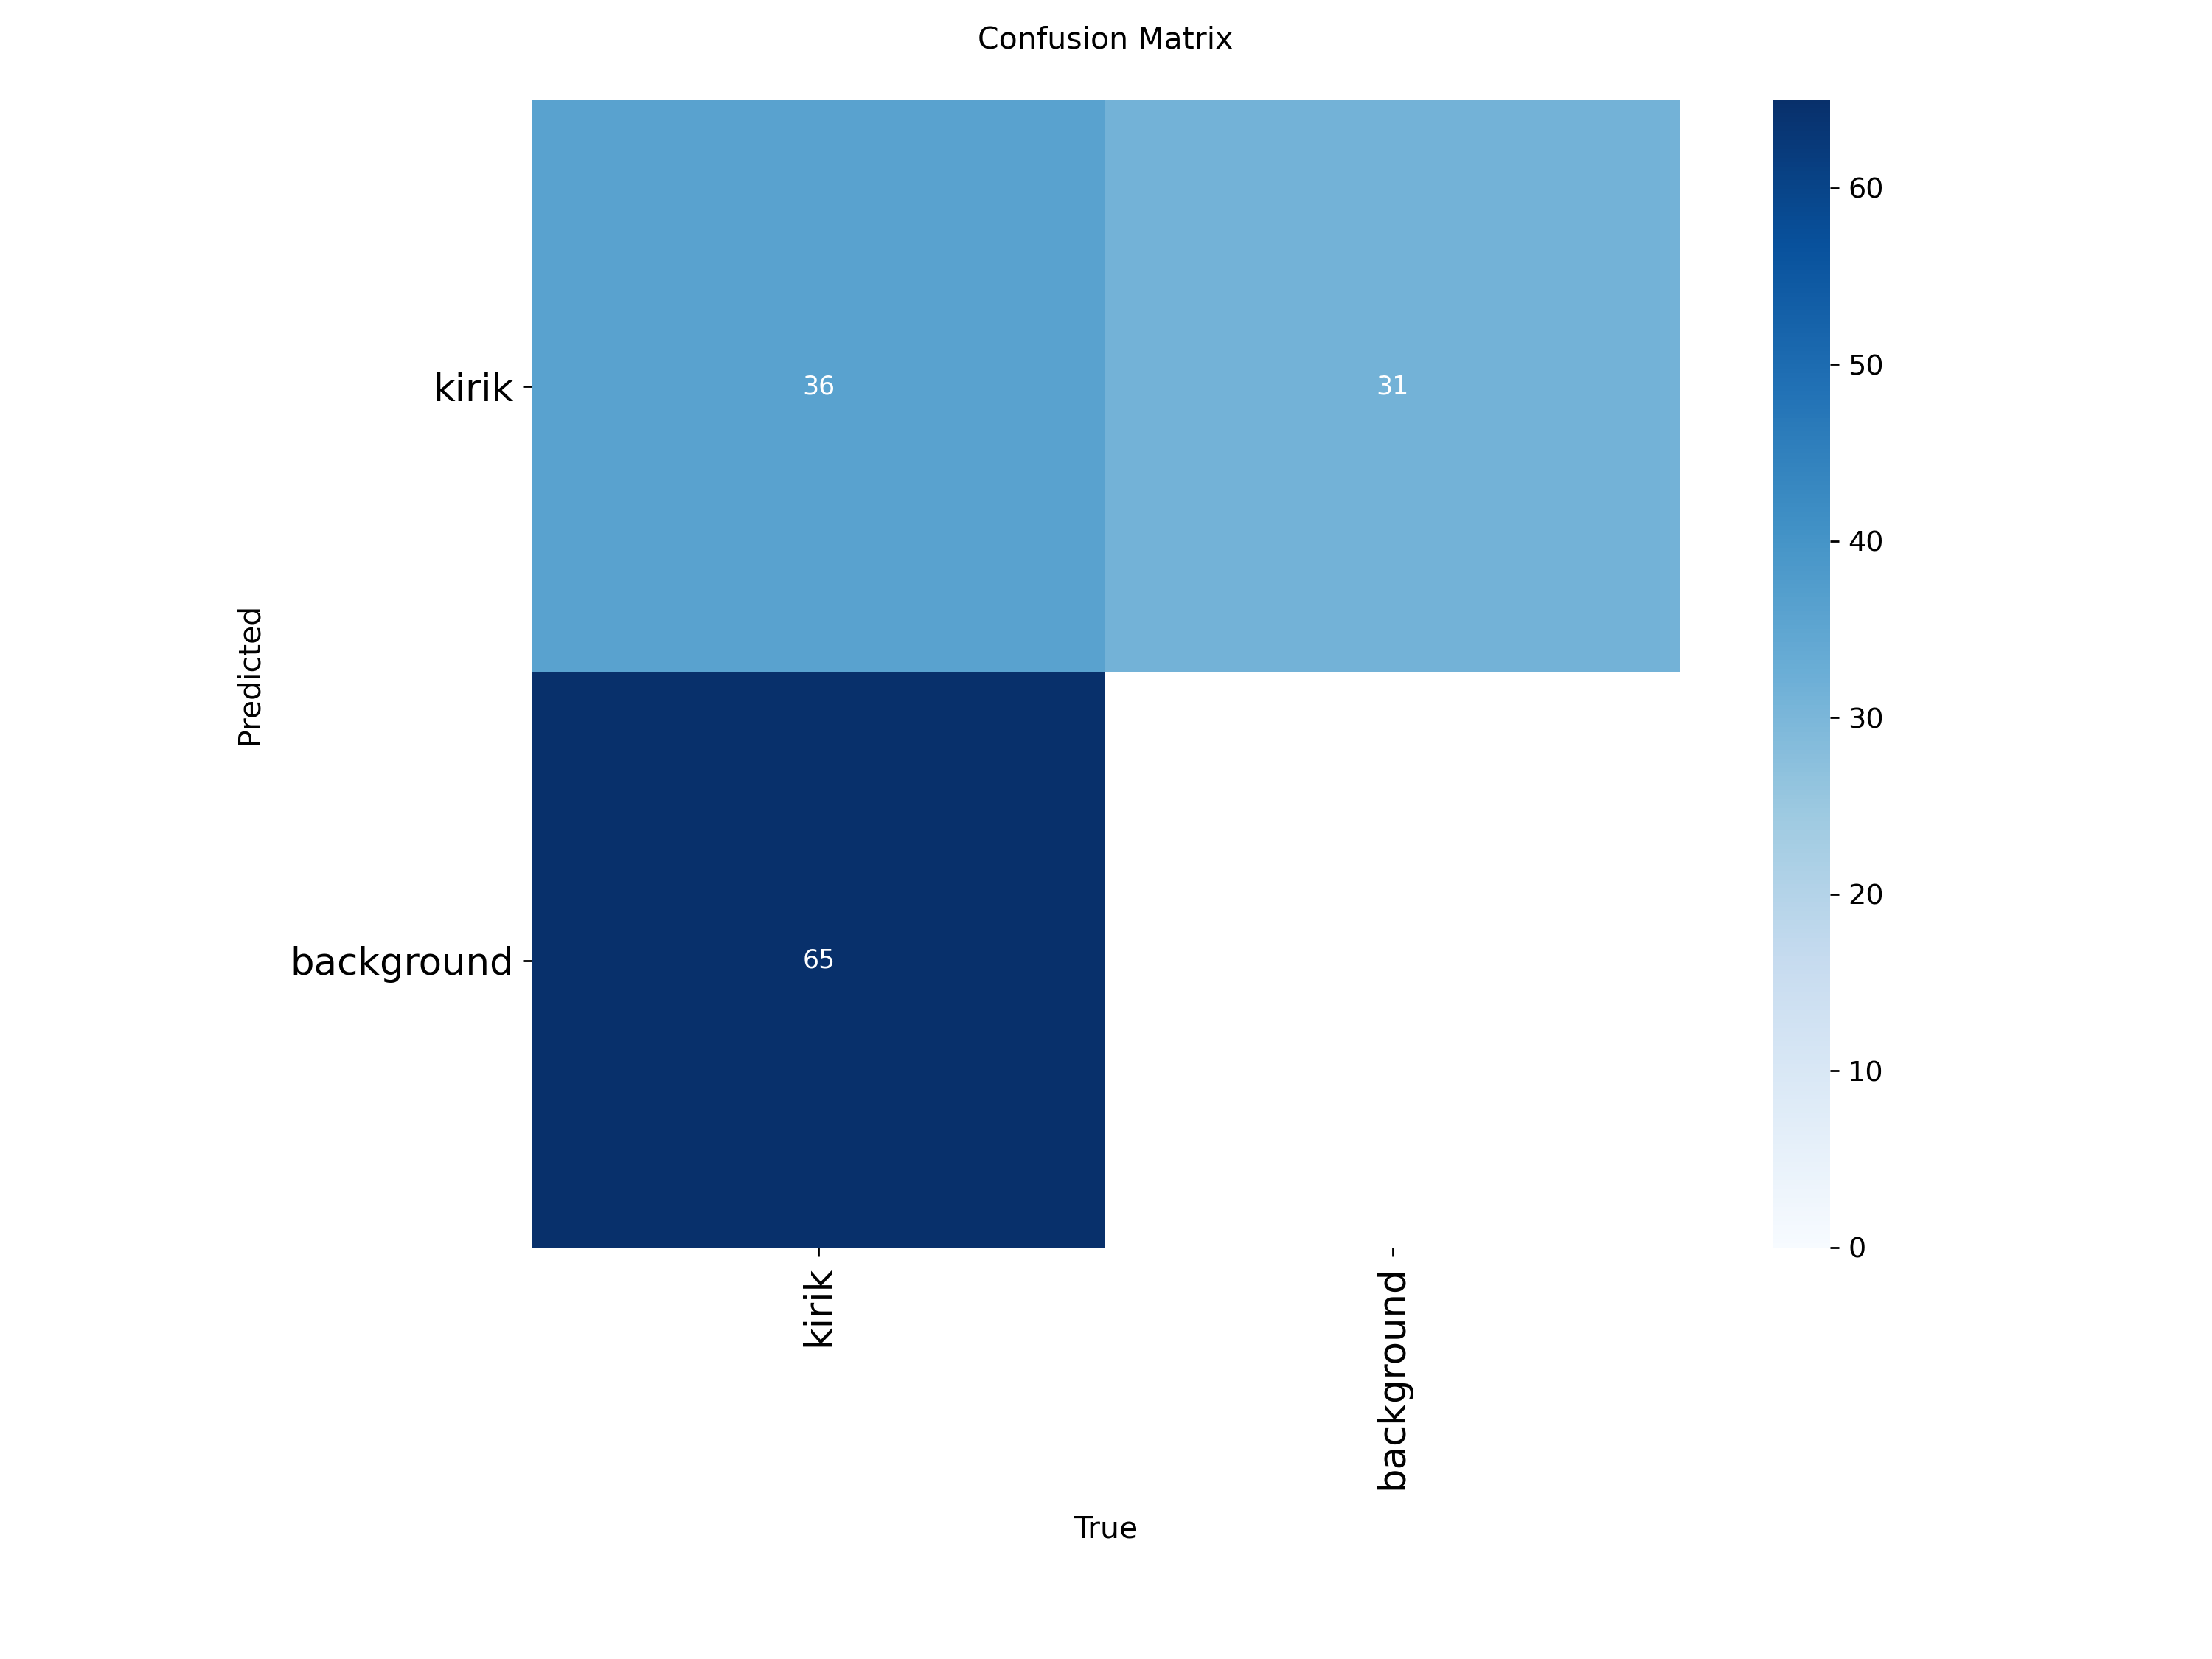

In [15]:
%cd {RUNS_ROOT}
Image(filename=f'{RUNS_ROOT}/exp1/confusion_matrix.png', width=600)

/content/drive/MyDrive/yolov8-fracture-detection/runs


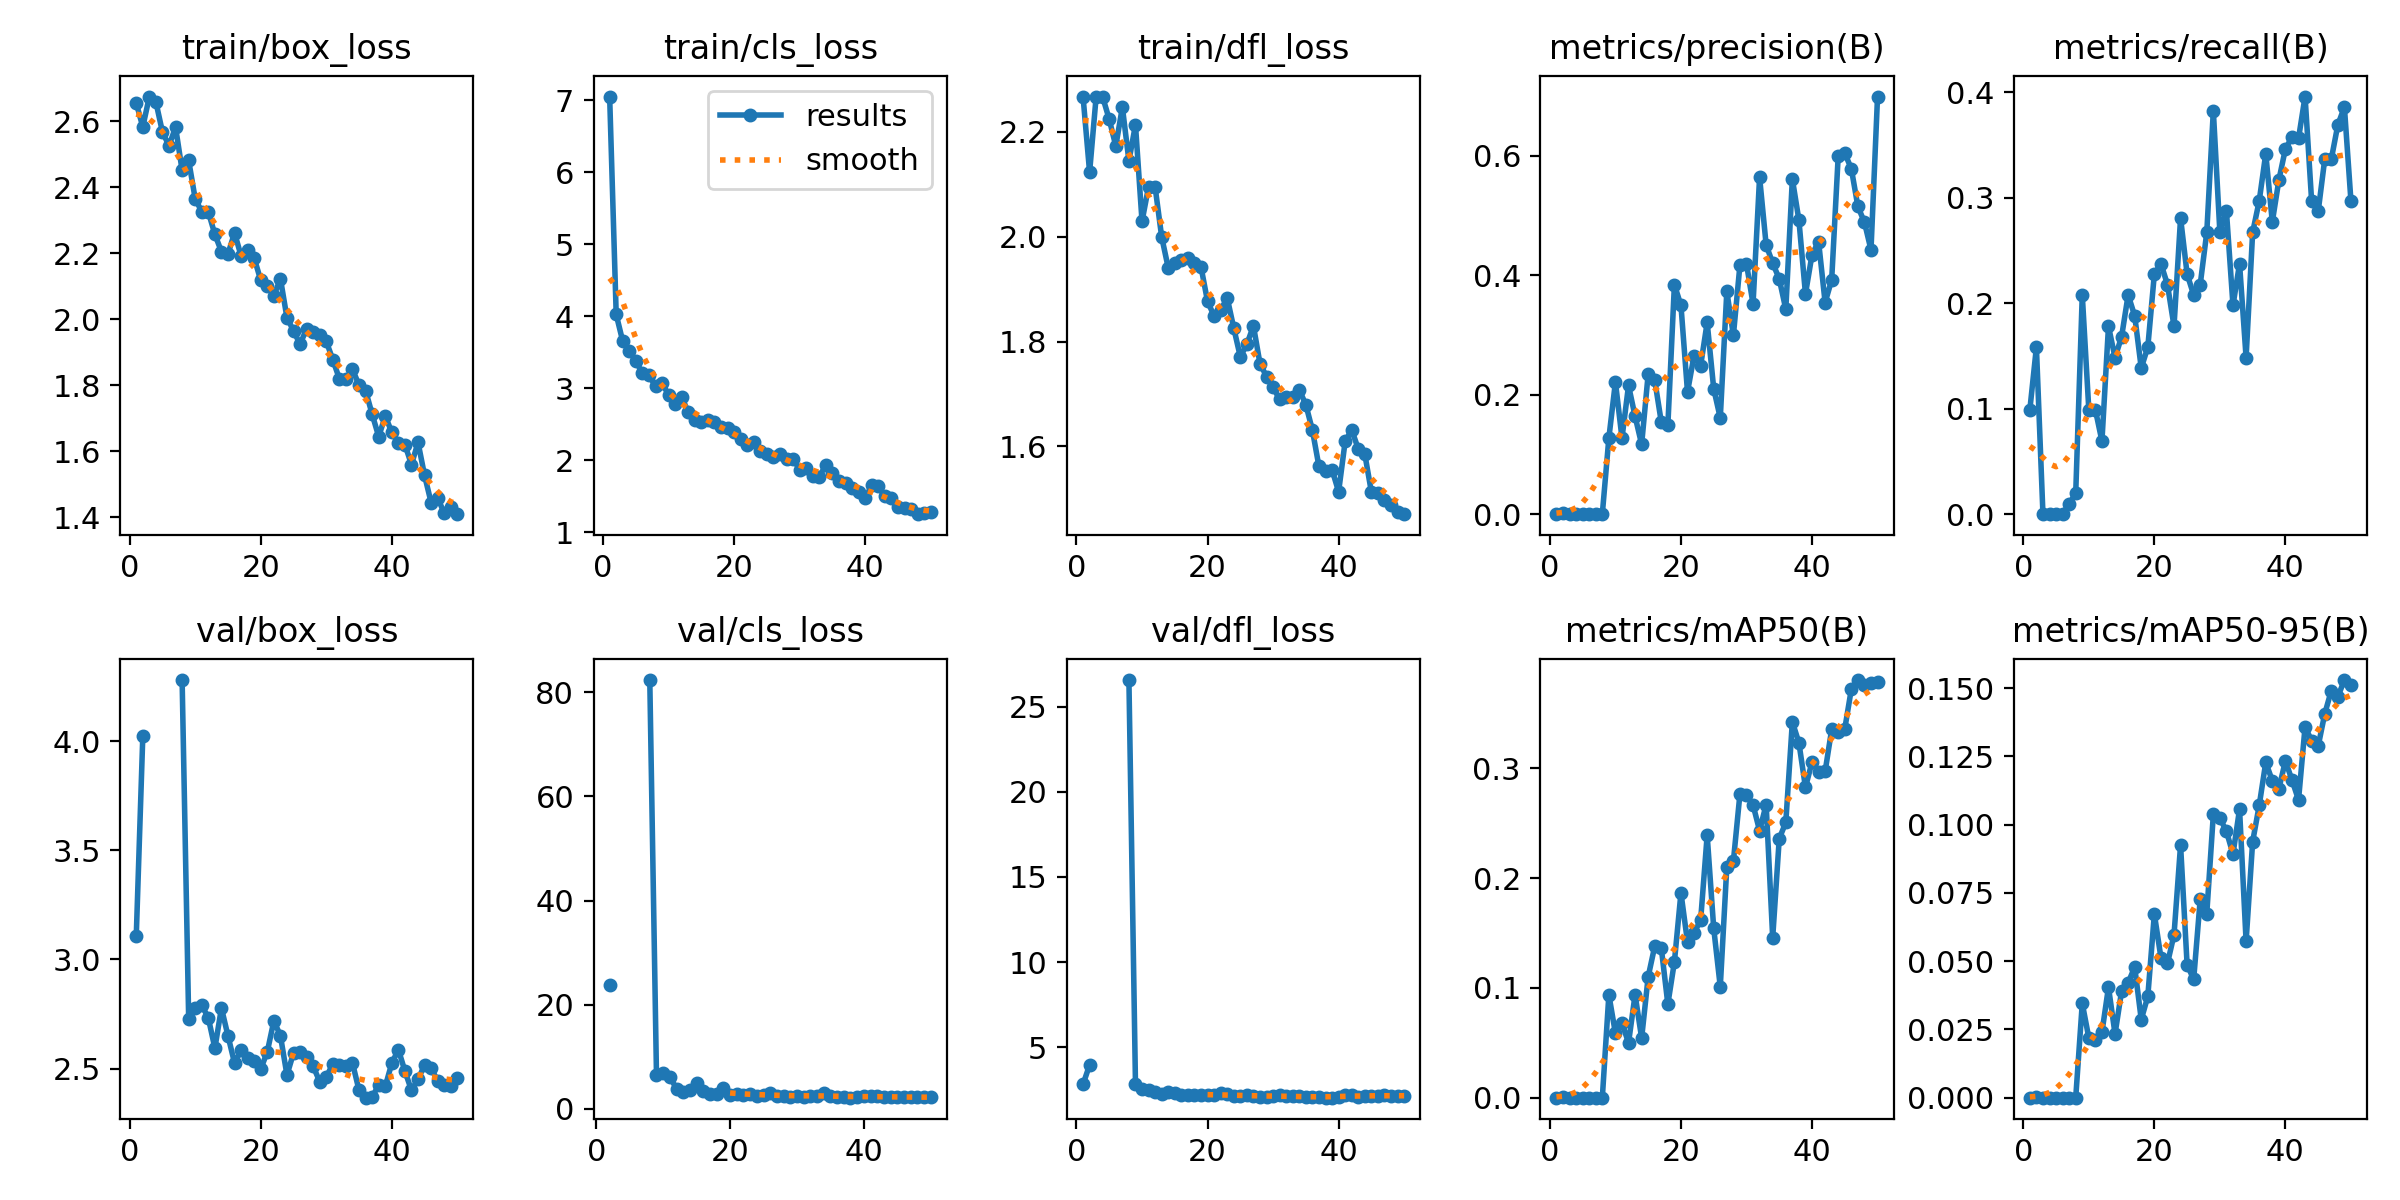

In [ ]:
%cd {RUNS_ROOT}
Image(filename=f'{RUNS_ROOT}/exp1/results.png', width=700)

/content/drive/MyDrive/yolov8-fracture-detection/runs


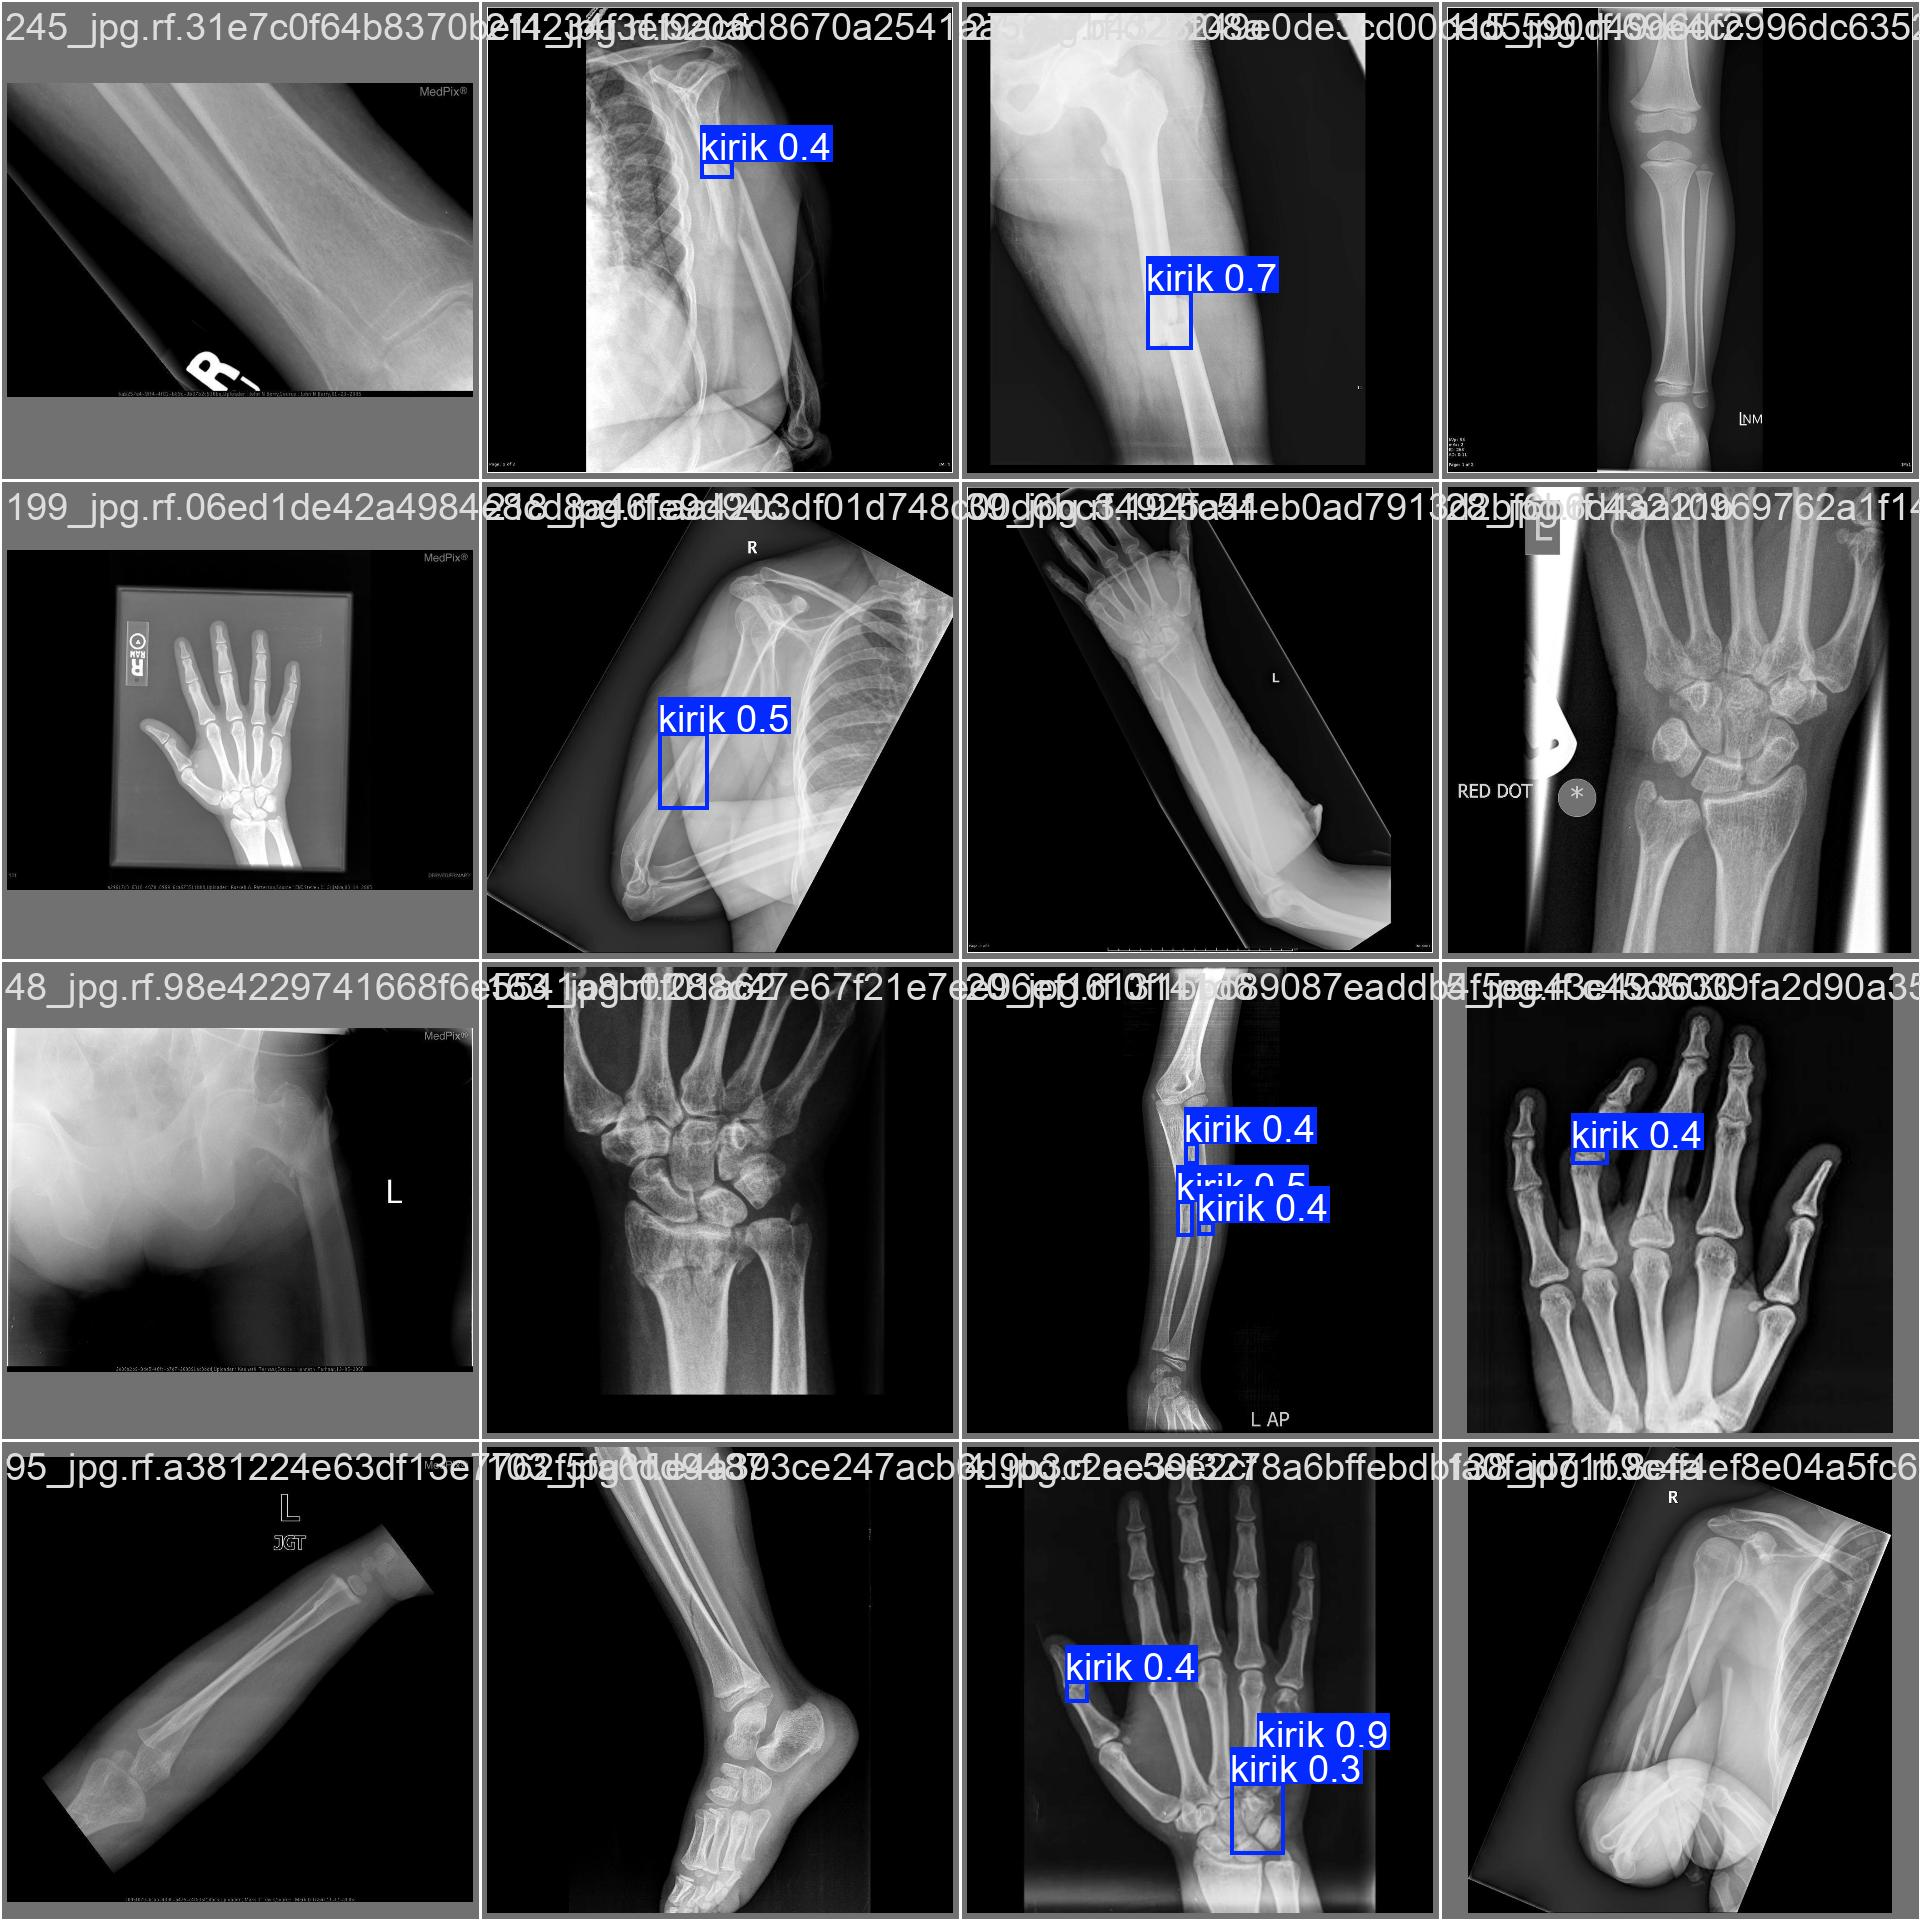

In [18]:
%cd {RUNS_ROOT}
Image(filename=f'{RUNS_ROOT}/exp1/val_batch0_pred.jpg', width=600)

# Inference on trained model

In [19]:
from ultralytics import YOLO
import random

# Load the trained model
model = YOLO(WEIGHTS_ROOT / "fracture_yolov8n_v1.pt")
test_images_path = DATA_ROOT / "test" / "images"

# Check if the path exists
if not test_images_path.exists():
    print(f"Warning: Test images path not found at {test_images_path}. Skipping inference.")
else:
    # Get a list of all image files in the test directory
    image_files = list(test_images_path.glob("*.jpg")) + list(test_images_path.glob("*.jpeg")) + list(test_images_path.glob("*.png"))

    if not image_files:
        print(f"Warning: No images found in {test_images_path}. Skipping inference.")
    else:
        # Select up to 10 random images for inference
        num_images_to_predict = min(10, len(image_files))
        selected_images = random.sample(image_files, num_images_to_predict)

        print(f"Performing inference on {num_images_to_predict} test images...")
        # Perform prediction and display results for each image
        for img_path in selected_images:
            print(f"\nPredicting on: {img_path.name}")
            results = model.predict(source=str(img_path), save=True, imgsz=IMAGE_SIZE, conf=0.25)
            # The 'show=True' argument will display the image with predictions automatically.
            # The 'save=True' argument saves the predicted images to runs/detect/predict*/

print("Inference block complete.")

Performing inference on 10 test images...

Predicting on: 10_jpg.rf.f27a7c3b504e2a4785d2bb7fcf44e2c4.jpg

image 1/1 /content/drive/MyDrive/yolov8-fracture-detection/data/test/images/10_jpg.rf.f27a7c3b504e2a4785d2bb7fcf44e2c4.jpg: 1024x1024 (no detections), 72.8ms
Speed: 3.9ms preprocess, 72.8ms inference, 0.8ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to /content/drive/MyDrive/yolov8-fracture-detection/runs/runs/detect/predict

Predicting on: 197_jpg.rf.3926b25ad0cb271e05f3b5f4c077aea6.jpg

image 1/1 /content/drive/MyDrive/yolov8-fracture-detection/data/test/images/197_jpg.rf.3926b25ad0cb271e05f3b5f4c077aea6.jpg: 768x1024 (no detections), 59.8ms
Speed: 4.6ms preprocess, 59.8ms inference, 0.6ms postprocess per image at shape (1, 3, 768, 1024)
Results saved to /content/drive/MyDrive/yolov8-fracture-detection/runs/runs/detect/predict

Predicting on: 10_jpg.rf.1e3fb2bda38184711153eaaeb40c0426.jpg

image 1/1 /content/drive/MyDrive/yolov8-fracture-detection/data/test/i

**Now** Let's take a look at few results.

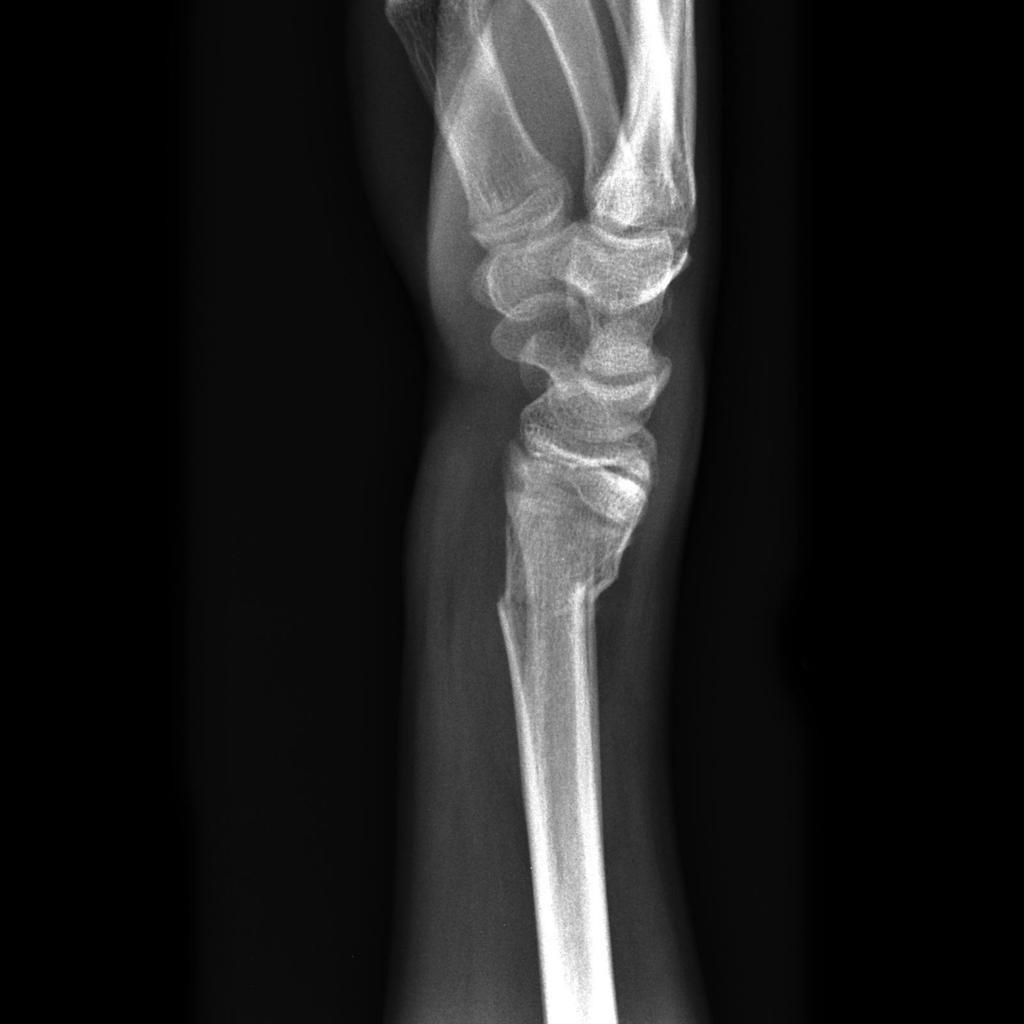

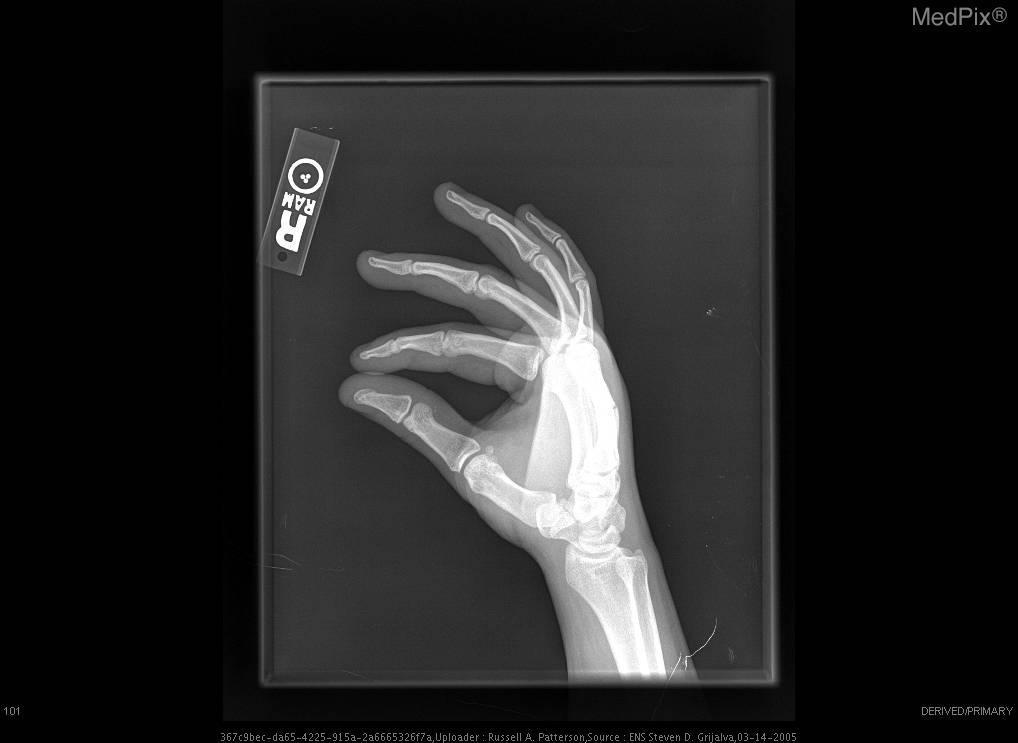

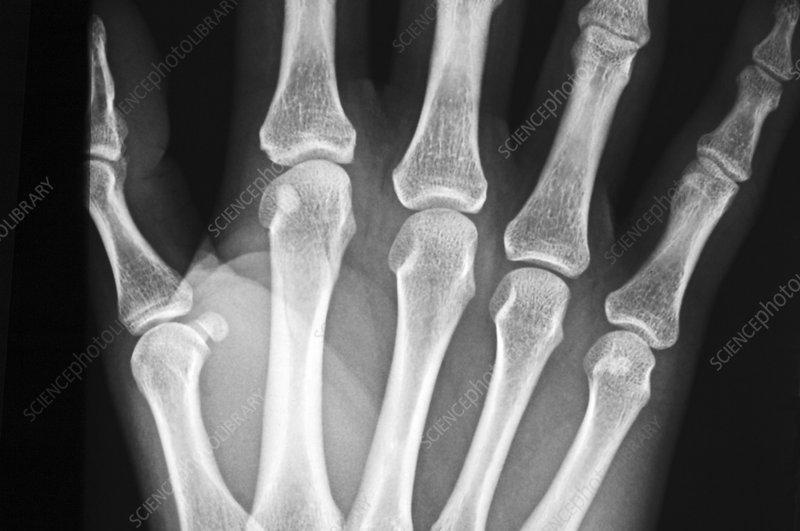

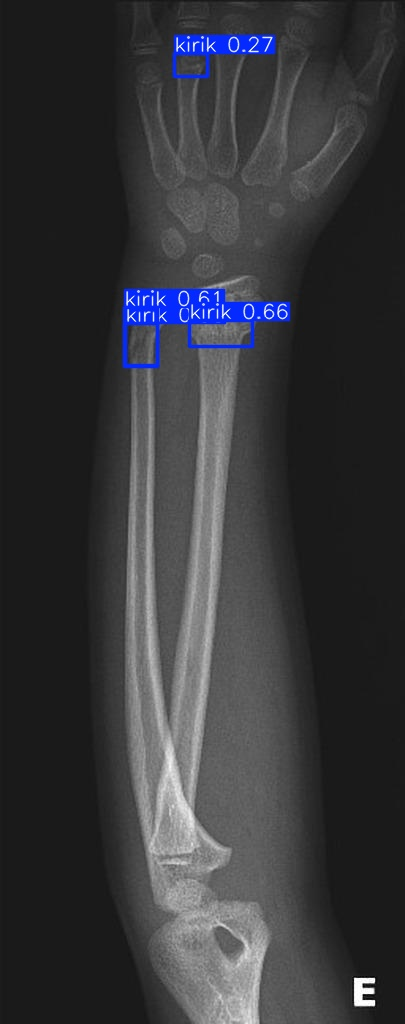

In [29]:
import glob
from IPython.display import Image, display

# Define the base path where the folders are located
base_path = RUNS_ROOT / "runs" /"detect"

# List all directories that start with 'predict' in the base path
subfolders = [os.path.join(base_path, d) for d in os.listdir(base_path)
              if os.path.isdir(os.path.join(base_path, d)) and d.startswith('predict')]

# Find the latest folder by modification time
latest_folder = max(subfolders, key=os.path.getmtime)

image_paths = glob.glob(f'{latest_folder}/*.jpg')[:4]

# Display each image
for image_path in image_paths:
    display(Image(filename=image_path, width=600))

## Next step

Open `03_evaluate_predict.ipynb` and set `WEIGHTS_PATH` to the saved path printed above.
